In [1]:
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os

In [2]:
# --- KONFIGURASI ---
initial_train_years = 2  # Pakai 2 tahun pertama untuk training awal
rebalance_days = 90      # Re-train model setiap 3 bulan (90 hari)
n_states = 3             # Jumlah regime


In [3]:
save_path_feature = os.path.join('..', 'data', 'btc_usd_coinbase_features_v2.csv')
btc_features_v2=pd.read_csv(save_path_feature)

In [4]:
btc_features_v2['timestamp'] = pd.to_datetime(btc_features_v2['timestamp'])
btc_features_v2.set_index('timestamp', inplace=True)

In [5]:
import sys
import pandas as pd
# Import modul lokal (pastikan folder src ada di direktori yang tepat)
sys.path.append('../src')
from regime_HMM import RegimeHMM

df_wf = btc_features_v2.copy() 
feature_cols = ['log_return', 'volatility', 'trend_slope', 'volume_zscore', 'price_dist_ma']
hmm_model = RegimeHMM(n_components=3, random_state=42)

# Siapkan tempat menampung prediksi
wf_regimes = []
wf_dates = []

# Tentukan titik potong awal
start_idx = int(365 * initial_train_years)
total_rows = len(df_wf)
# ... (Setup awal sama: feature_cols, start_idx, dll) ...

# Siapkan tempat menampung
wf_regimes = []      # Hard Label (Viterbi)
wf_probs = []        # Probability distribution (Forward)
wf_dates = []

# List untuk menyimpan snapshot Transition Matrix (misal setiap ganti window)
transmat_history = [] 

print(f"Total Data: {total_rows} hari.")
print(f"Start Walk-Forward (Strict Mode)...")

# --- LOOP WALK-FORWARD ---
for t in range(start_idx, total_rows, rebalance_days):
    # Slice Data
    train_df = df_wf.iloc[:t]
    end_t = min(t + rebalance_days, total_rows)
    test_df = df_wf.iloc[t:end_t]

    if len(test_df) == 0:
        break

    # 1. Train Model (Gunakan Class Wrapper kita yang ada di hmm_model.py)
    # Class ini otomatis melakukan Scaling & Return-Based Mapping saat .fit()
    hmm_model.fit(train_df, feature_cols)
    
    # Simpan Transition Matrix saat ini untuk dianalisis nanti
    transmat_history.append({
        'date': test_df.index[0],
        'matrix': hmm_model.model.transmat_, # Matrix murni dari model
        'mapping': hmm_model.state_mapping   # Mapping state saat itu
    })

    # Siapkan data untuk prediksi step-by-step
    # Kita butuh scaler yang sama dengan training
    X_train_scaled = hmm_model.scaler.transform(train_df[feature_cols].values)
    X_test_scaled = hmm_model.scaler.transform(test_df[feature_cols].values)

    # 2. STRICT PREDICTION LOOP (Satu per satu)
    for i in range(len(test_df)):
        # Gabungkan History + Hari ini (TANPA MASA DEPAN)
        # X_current adalah data dari awal waktu sampai hari ke-i di window test
        X_current = np.vstack([X_train_scaled, X_test_scaled[:i+1]])

        # A. Viterbi Path (Hard Prediction)
        # Ambil elemen terakhir [-1]
        viterbi_state_raw = hmm_model.model.predict(X_current)[-1]
        
        # B. Forward Probabilities (Soft Prediction)
        # Ambil baris terakhir [-1]. Ini P(State | Data sampai hari ini)
        forward_prob_raw = hmm_model.model.predict_proba(X_current)[-1]
        
        # --- MAPPING HASIL (PENTING!) ---
        # State mentah (0,1,2) dari model bisa berubah arti tiap training.
        # Kita harus memetakan ke label standar kita: 0=Crash, 1=Sideways, 2=Bull
        
        # 1. Map Hard Label
        final_regime = hmm_model.state_mapping[viterbi_state_raw]
        
        # 2. Map Probabilities (Kolom harus ditukar sesuai mapping!)
        # Contoh: Jika model state 0 -> Bull (Label 2), maka prob di index 0 harus pindah ke index 2.
        final_prob = np.zeros(3)
        for raw_state, target_label in hmm_model.state_mapping.items():
            final_prob[target_label] = forward_prob_raw[raw_state]
            
        wf_regimes.append(final_regime)
        wf_probs.append(final_prob)
        wf_dates.append(test_df.index[i])

    print(f"-> Batch {test_df.index[0].date()} selesai.")



Total Data: 3822 hari.
Start Walk-Forward (Strict Mode)...
-> Batch 2017-09-11 selesai.
-> Batch 2017-12-10 selesai.
-> Batch 2018-03-10 selesai.
-> Batch 2018-06-08 selesai.
-> Batch 2018-09-06 selesai.
-> Batch 2018-12-05 selesai.
-> Batch 2019-03-05 selesai.
-> Batch 2019-06-03 selesai.
-> Batch 2019-09-01 selesai.
-> Batch 2019-11-30 selesai.
-> Batch 2020-02-28 selesai.
-> Batch 2020-05-28 selesai.
-> Batch 2020-08-26 selesai.
-> Batch 2020-11-24 selesai.
-> Batch 2021-02-22 selesai.
-> Batch 2021-05-23 selesai.
-> Batch 2021-08-21 selesai.
-> Batch 2021-11-19 selesai.
-> Batch 2022-02-17 selesai.
-> Batch 2022-05-18 selesai.
-> Batch 2022-08-16 selesai.
-> Batch 2022-11-14 selesai.
-> Batch 2023-02-12 selesai.
-> Batch 2023-05-13 selesai.
-> Batch 2023-08-11 selesai.
-> Batch 2023-11-09 selesai.
-> Batch 2024-02-07 selesai.
-> Batch 2024-05-07 selesai.
-> Batch 2024-08-05 selesai.
-> Batch 2024-11-03 selesai.
-> Batch 2025-02-01 selesai.
-> Batch 2025-05-02 selesai.
-> Batch 2025

In [6]:
# --- GABUNGKAN HASIL ---
df_results = pd.DataFrame({
    'regime_wf_viterbi': wf_regimes,
    'prob_crash': [p[0] for p in wf_probs],    # Probabilitas Crash
    'prob_sideways': [p[1] for p in wf_probs], # Probabilitas Sideways
    'prob_bull': [p[2] for p in wf_probs]      # Probabilitas Bull
}, index=wf_dates)

df_final = df_wf.join(df_results, how='inner')
print("Selesai! Data 'prob_crash', 'prob_sideways', 'prob_bull' siap dianalisis.")

Selesai! Data 'prob_crash', 'prob_sideways', 'prob_bull' siap dianalisis.


In [7]:
df_final['regime_wf_forward'] = df_final[['prob_crash', 'prob_sideways', 'prob_bull']].values.argmax(axis=1)

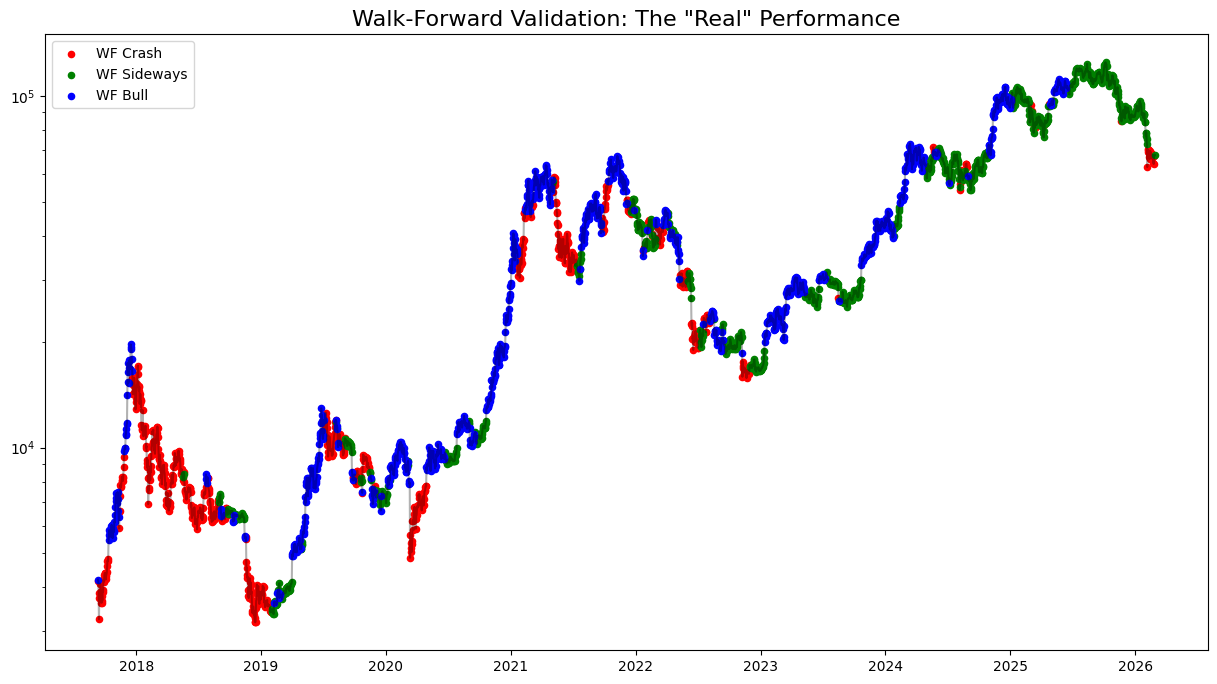

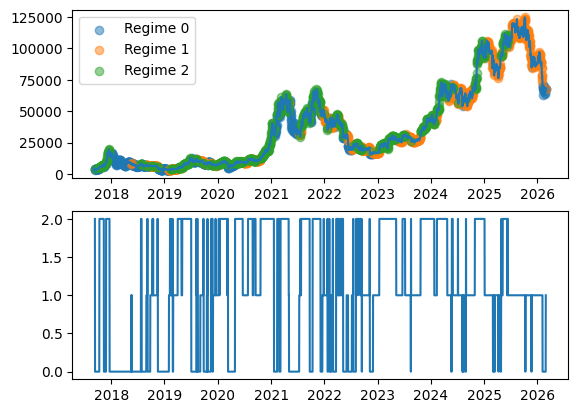

In [8]:
plt.figure(figsize=(15, 8))

subset=df_final.copy()
# Ambil data hanya yang punya hasil WF
subset = subset.dropna(subset=['regime_wf_forward'])

# Plot Harga
plt.plot(subset.index, subset['close'], color='black', alpha=0.3)

# Scatter Plot Regime WF
# 0=Merah (Crash), 1=Hijau (Sideways), 2=Biru (Bull)
colors = ['red', 'green', 'blue']
labels = ['WF Crash', 'WF Sideways', 'WF Bull']

for i in range(3):
    mask = subset['regime_wf_forward'] == i
    plt.scatter(subset.index[mask], subset.loc[mask, 'close'],
                s=20, c=colors[i], label=labels[i])

plt.title('Walk-Forward Validation: The "Real" Performance', fontsize=16)
plt.yscale('log')
plt.legend()
plt.show()

# Visualize regimes
fig, axes = plt.subplots(2, 1)
axes[0].plot(df_final.index, df_final['close'])
for regime in range(3):
    mask = df_final['regime_wf_forward'] == regime
    axes[0].scatter(df_final.index[mask], df_final['close'][mask], 
                   label=f'Regime {regime}', alpha=0.5)
axes[1].plot(df_final['regime_wf_forward'])
axes[0].legend()
plt.show()

In [9]:
df_final[['regime_wf_forward']].value_counts()

regime_wf_forward
1                    1136
2                    1108
0                     848
Name: count, dtype: int64

In [10]:
df_final.to_csv(os.path.join('..', 'data', 'btc_usd_coinbase_features_with_wf.csv'))